# 🔧 MADELON Dataset — Data Preprocessing
### Role: Data Preprocessing Engineer
---
| | |
|---|---|
| **Dataset** | MADELON (UCI ML Repository) |
| **Samples** | 2,000 |
| **Features** | 500 numeric features |
| **Ground Truth** | Binary labels: +1 / -1 |
| **Scalers** | StandardScaler · MinMaxScaler |
---

### Responsibilities
- Feature scaling
- Normalization
- Cleaning
- Feature engineering
- Prepare dataset for clustering

### Deliverables
- ✅ StandardScaler implementation
- ✅ Clean preprocessing pipeline
- ✅ MinMaxScaler comparison

## 📦 Step 0 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("✅ All libraries imported!")

✅ All libraries imported!


## 📂 Step 1 — Load Data

In [2]:
# Load combined dataset (train + validation already merged in mdlon.csv)
df = pd.read_csv(r'C:\3.2 notes and cats\madelon dataset\mdlon.csv')

X_all = df.iloc[:, :-1].copy()
y_all = df.iloc[:, -1].copy()

# Name features
X_all.columns = [f'f{i}' for i in range(X_all.shape[1])]

print(f"Combined shape : {X_all.shape}")
print(f"Ground truth   : {y_all.unique()} (used only for external metrics)")

Combined shape : (2000, 500)
Ground truth   : [-1  1] (used only for external metrics)


## 🔍 Step 2 — Raw Data Inspection

Before scaling, we need to understand what we are working with.
MADELON features range from **0 to 999** — a huge range that will
bias any distance-based algorithm toward high-value features.

In [3]:
print("=== Dataset Info ===")
print(f"Samples  : {X_all.shape[0]}")
print(f"Features : {X_all.shape[1]}")
print(f"Missing  : {X_all.isnull().sum().sum()}")
print(f"Feature range: min={X_all.min().min():.1f}, max={X_all.max().max():.1f}")
print()
print("=== Ground Truth Distribution ===")
print(y_all.value_counts())
print()
print("✅ No missing values — dataset is clean!")

=== Dataset Info ===
Samples  : 2000
Features : 500
Missing  : 0
Feature range: min=0.0, max=999.0

=== Ground Truth Distribution ===
T
-1    1000
 1    1000
Name: count, dtype: int64

✅ No missing values — dataset is clean!


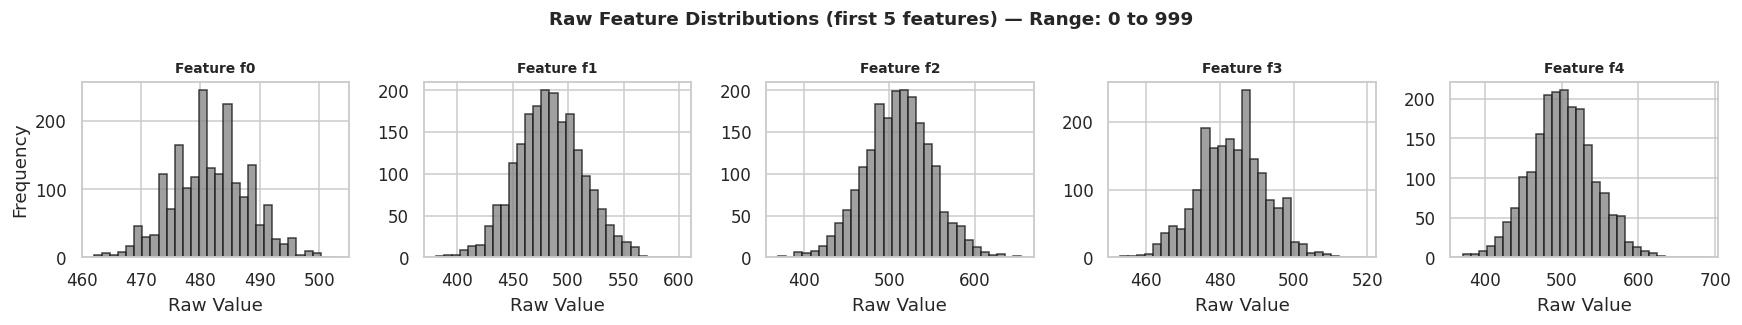

In [4]:
# Raw feature distribution — first 5 features
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.hist(X_all.iloc[:, i], bins=30, color='#888888', edgecolor='k', alpha=0.8)
    ax.set_title(f'Feature f{i}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Raw Value')
    if i == 0:
        ax.set_ylabel('Frequency')
plt.suptitle('Raw Feature Distributions (first 5 features) — Range: 0 to 999',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

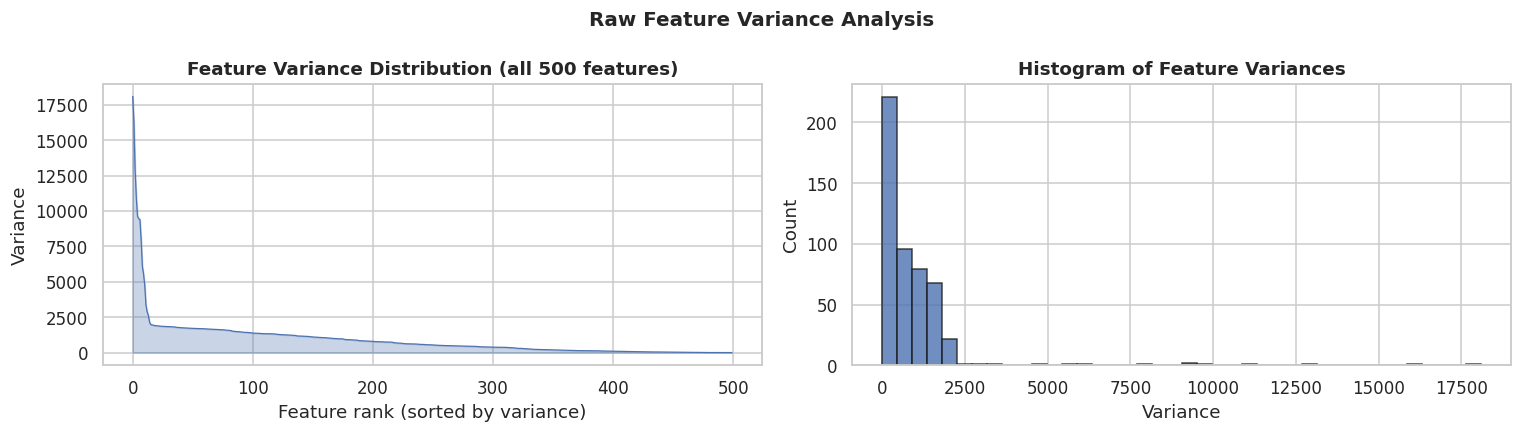

Max variance : 18104.93
Min variance : 0.35
Mean variance: 911.89

⚠️  Variance ranges widely — scaling is essential!


In [5]:
# Feature variance distribution across all 500 features
variances = X_all.var().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(len(variances)), variances.values, color='#4C72B0', linewidth=0.8)
axes[0].fill_between(range(len(variances)), variances.values, alpha=0.3, color='#4C72B0')
axes[0].set_title('Feature Variance Distribution (all 500 features)', fontweight='bold')
axes[0].set_xlabel('Feature rank (sorted by variance)')
axes[0].set_ylabel('Variance')

axes[1].hist(variances.values, bins=40, color='#4C72B0', edgecolor='k', alpha=0.8)
axes[1].set_title('Histogram of Feature Variances', fontweight='bold')
axes[1].set_xlabel('Variance'); axes[1].set_ylabel('Count')

plt.suptitle('Raw Feature Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Max variance : {variances.max():.2f}")
print(f"Min variance : {variances.min():.2f}")
print(f"Mean variance: {variances.mean():.2f}")
print(f"\n⚠️  Variance ranges widely — scaling is essential!")

## ⚙️ Step 3 — StandardScaler Implementation

**Why StandardScaler?**
MADELON features range from 0–999. Distance-based algorithms (K-Means, DBSCAN, Hierarchical)
are sensitive to scale — a feature with large values would dominate distance calculations unfairly.

**Formula:** `z = (x − mean) / std`

StandardScaler transforms every feature to have **mean = 0** and **std = 1**.

In [6]:
# ── DELIVERABLE 1: StandardScaler Implementation ────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

print("=== StandardScaler Results ===")
print(f"Input  shape : {X_all.shape}")
print(f"Output shape : {X_scaled.shape}")
print()
print(f"Before scaling — mean (f0–f4): {X_all.iloc[:, :5].mean().round(2).values}")
print(f"Before scaling — std  (f0–f4): {X_all.iloc[:, :5].std().round(2).values}")
print()
print(f"After scaling  — mean (f0–f4): {X_scaled[:, :5].mean(axis=0).round(4)}")
print(f"After scaling  — std  (f0–f4): {X_scaled[:, :5].std(axis=0).round(4)}")
print()
print("✅ All features now have mean≈0 and std≈1")

=== StandardScaler Results ===
Input  shape : (2000, 500)
Output shape : (2000, 500)

Before scaling — mean (f0–f4): [481.72 483.45 510.17 483.38 501.61]
Before scaling — std  (f0–f4): [ 6.42 30.19 38.9   9.06 41.39]

After scaling  — mean (f0–f4): [-0.  0.  0. -0. -0.]
After scaling  — std  (f0–f4): [1. 1. 1. 1. 1.]

✅ All features now have mean≈0 and std≈1


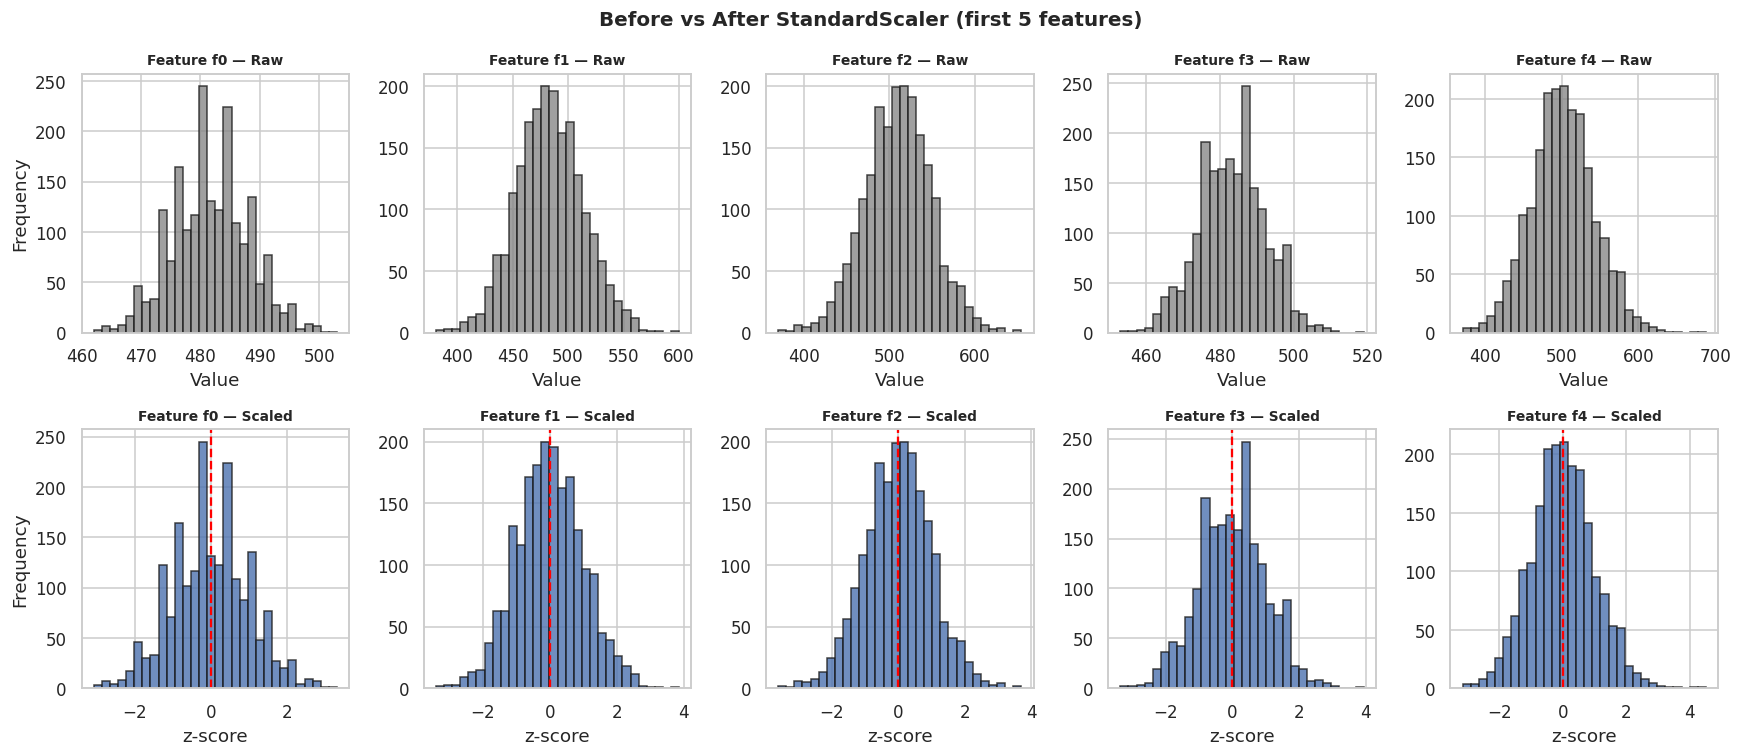

In [7]:
# Before vs After StandardScaler — visual comparison
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for i in range(5):
    # Raw
    axes[0, i].hist(X_all.iloc[:, i], bins=30, color='#888888', edgecolor='k', alpha=0.8)
    axes[0, i].set_title(f'Feature f{i} — Raw', fontsize=9, fontweight='bold')
    axes[0, i].set_xlabel('Value')
    if i == 0: axes[0, i].set_ylabel('Frequency')

    # Scaled
    axes[1, i].hist(X_scaled[:, i], bins=30, color='#4C72B0', edgecolor='k', alpha=0.8)
    axes[1, i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1, i].set_title(f'Feature f{i} — Scaled', fontsize=9, fontweight='bold')
    axes[1, i].set_xlabel('z-score')
    if i == 0: axes[1, i].set_ylabel('Frequency')

plt.suptitle('Before vs After StandardScaler (first 5 features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

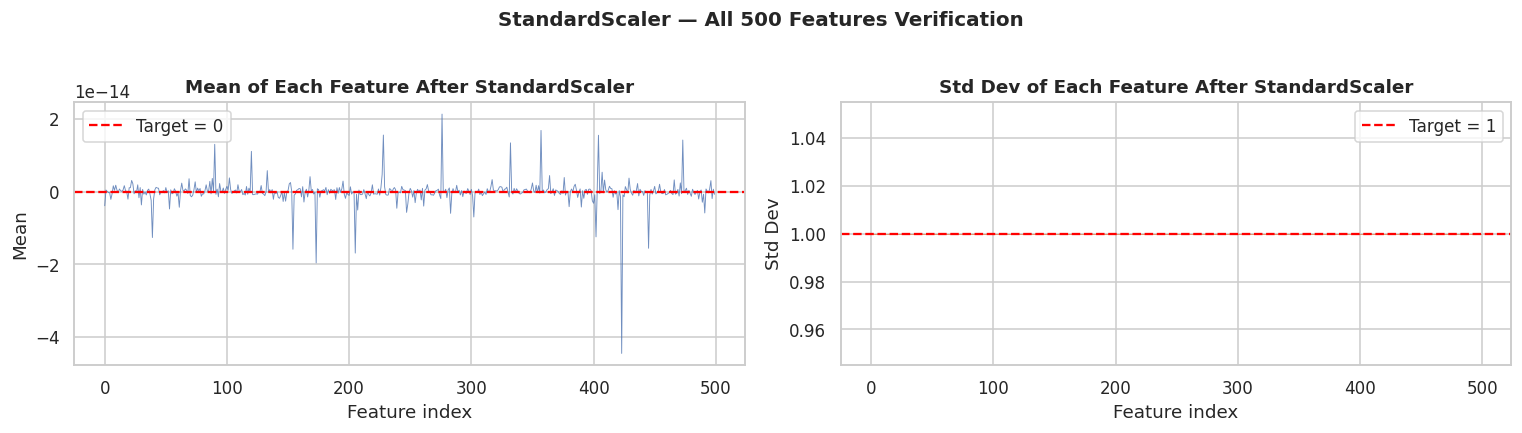

Global mean across all features: -0.000000  ✅ ≈ 0
Global std  across all features: 1.000000  ✅ ≈ 1


In [8]:
# Mean and Std across all 500 features after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

means_after = X_scaled.mean(axis=0)
stds_after  = X_scaled.std(axis=0)

axes[0].plot(means_after, color='#4C72B0', linewidth=0.6, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Target = 0')
axes[0].set_title('Mean of Each Feature After StandardScaler', fontweight='bold')
axes[0].set_xlabel('Feature index'); axes[0].set_ylabel('Mean')
axes[0].legend()

axes[1].plot(stds_after, color='#DD8452', linewidth=0.6, alpha=0.8)
axes[1].axhline(1, color='red', linestyle='--', linewidth=1.5, label='Target = 1')
axes[1].set_title('Std Dev of Each Feature After StandardScaler', fontweight='bold')
axes[1].set_xlabel('Feature index'); axes[1].set_ylabel('Std Dev')
axes[1].legend()

plt.suptitle('StandardScaler — All 500 Features Verification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Global mean across all features: {means_after.mean():.6f}  ✅ ≈ 0")
print(f"Global std  across all features: {stds_after.mean():.6f}  ✅ ≈ 1")

## 📊 Step 4 — MinMaxScaler Comparison

**Formula:** `z = (x − min) / (max − min)`

MinMaxScaler compresses all values into the range **[0, 1]**.
We compare it against StandardScaler to justify our choice.

In [9]:
# ── DELIVERABLE 3: MinMaxScaler ─────────────────────────────
mm_scaler = MinMaxScaler()
X_minmax  = mm_scaler.fit_transform(X_all)

print("=== MinMaxScaler Results ===")
print(f"Output shape : {X_minmax.shape}")
print(f"Min (f0–f4)  : {X_minmax[:, :5].min(axis=0).round(4)}")
print(f"Max (f0–f4)  : {X_minmax[:, :5].max(axis=0).round(4)}")
print("✅ All features now in range [0, 1]")

=== MinMaxScaler Results ===
Output shape : (2000, 500)
Min (f0–f4)  : [0. 0. 0. 0. 0.]
Max (f0–f4)  : [1. 1. 1. 1. 1.]
✅ All features now in range [0, 1]


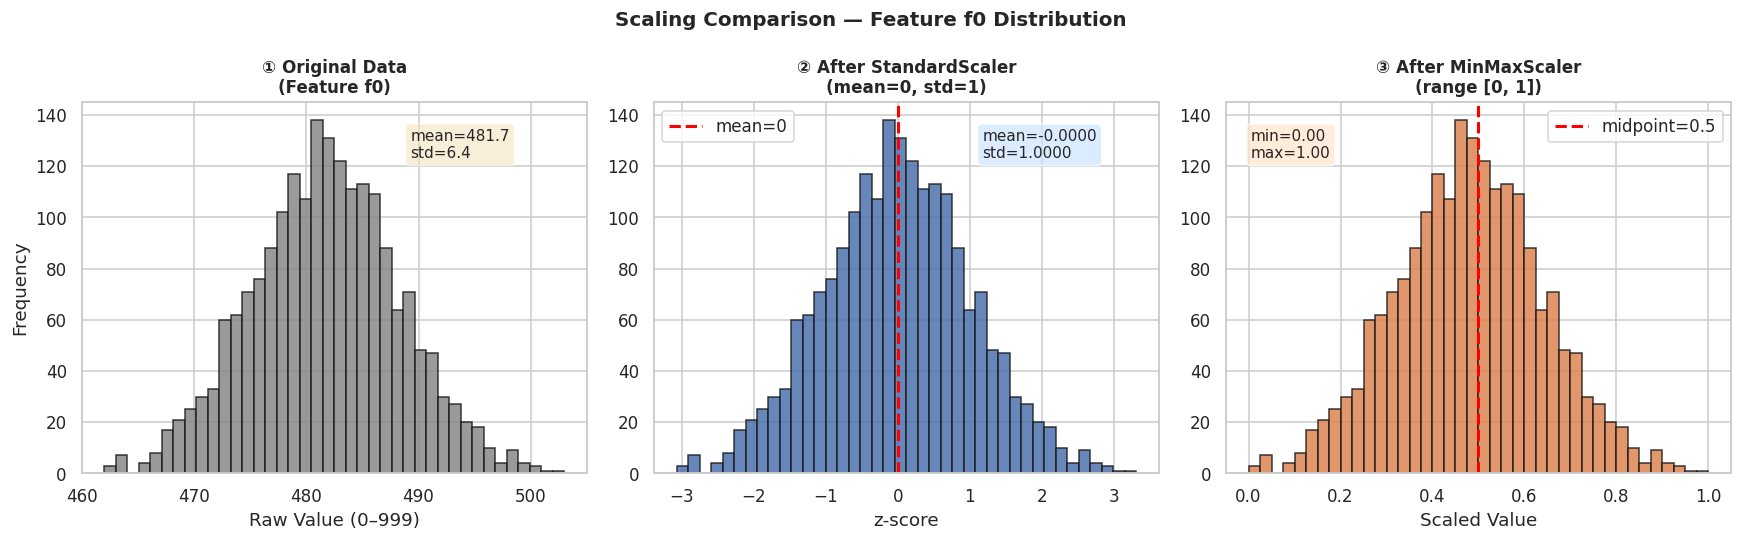

In [10]:
# Side-by-side: Raw vs StandardScaler vs MinMaxScaler (Feature 0)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(X_all.iloc[:, 0], bins=40, color='#888888', edgecolor='k', alpha=0.85)
axes[0].set_title('① Original Data\n(Feature f0)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Raw Value (0–999)'); axes[0].set_ylabel('Frequency')
axes[0].annotate(f"mean={X_all.iloc[:,0].mean():.1f}\nstd={X_all.iloc[:,0].std():.1f}",
                 xy=(0.65,0.85), xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].hist(X_scaled[:, 0], bins=40, color='#4C72B0', edgecolor='k', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='mean=0')
axes[1].set_title('② After StandardScaler\n(mean=0, std=1)', fontweight='bold', fontsize=11)
axes[1].set_xlabel('z-score'); axes[1].legend()
axes[1].annotate(f"mean={X_scaled[:,0].mean():.4f}\nstd={X_scaled[:,0].std():.4f}",
                 xy=(0.65,0.85), xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='#cce5ff', alpha=0.7))

axes[2].hist(X_minmax[:, 0], bins=40, color='#DD8452', edgecolor='k', alpha=0.85)
axes[2].axvline(0.5, color='red', linestyle='--', linewidth=2, label='midpoint=0.5')
axes[2].set_title('③ After MinMaxScaler\n(range [0, 1])', fontweight='bold', fontsize=11)
axes[2].set_xlabel('Scaled Value'); axes[2].legend()
axes[2].annotate(f"min={X_minmax[:,0].min():.2f}\nmax={X_minmax[:,0].max():.2f}",
                 xy=(0.05,0.85), xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='#ffe5cc', alpha=0.7))

plt.suptitle('Scaling Comparison — Feature f0 Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

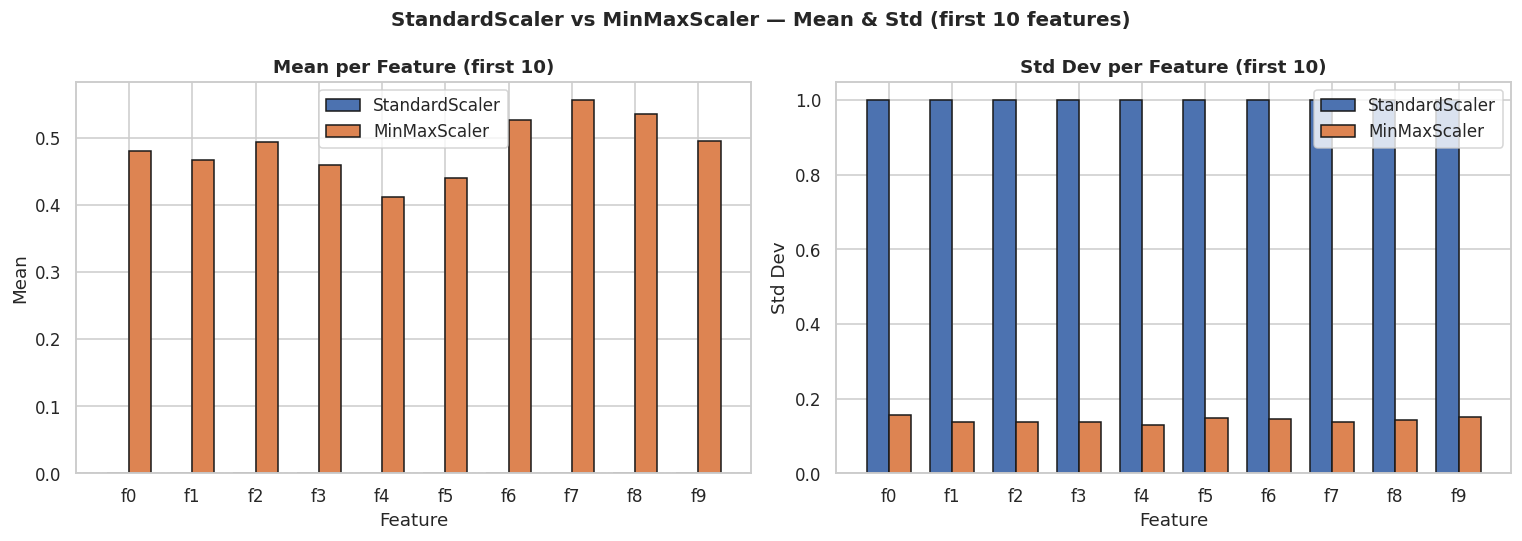

In [11]:
# Mean & Std comparison across first 10 features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x      = np.arange(10)
w      = 0.35
labels = [f'f{i}' for i in range(10)]

std_means = X_scaled[:, :10].mean(axis=0)
mm_means  = X_minmax[:, :10].mean(axis=0)
std_stds  = X_scaled[:, :10].std(axis=0)
mm_stds   = X_minmax[:, :10].std(axis=0)

axes[0].bar(x - w/2, std_means, w, label='StandardScaler', color='#4C72B0', edgecolor='k')
axes[0].bar(x + w/2, mm_means,  w, label='MinMaxScaler',   color='#DD8452', edgecolor='k')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Mean per Feature (first 10)', fontweight='bold')
axes[0].set_xlabel('Feature'); axes[0].set_ylabel('Mean')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels); axes[0].legend()

axes[1].bar(x - w/2, std_stds, w, label='StandardScaler', color='#4C72B0', edgecolor='k')
axes[1].bar(x + w/2, mm_stds,  w, label='MinMaxScaler',   color='#DD8452', edgecolor='k')
axes[1].set_title('Std Dev per Feature (first 10)', fontweight='bold')
axes[1].set_xlabel('Feature'); axes[1].set_ylabel('Std Dev')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels); axes[1].legend()

plt.suptitle('StandardScaler vs MinMaxScaler — Mean & Std (first 10 features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📋 Step 5 — Comparison Summary & Decision

| Metric | StandardScaler | MinMaxScaler |
|--------|---------------|--------------|
| Output mean | ≈ 0 | varies (0–1) |
| Output std | ≈ 1 | varies |
| Output range | unbounded | [0, 1] |
| Sensitive to outliers? | **Less** | **Yes** |
| Preserves shape of distribution? | ✅ Yes | ✅ Yes |
| Best for | Distance-based ML (K-Means, DBSCAN) | Neural nets / bounded input |
| **Used in this pipeline** | **✅ YES** | Comparison only |

**Decision:** StandardScaler is chosen because MADELON contains noisy features.
MinMaxScaler would compress those noisy extreme values into [0,1] but the relative
influence of outliers remains. StandardScaler is more robust for clustering tasks.

In [12]:
# Print final summary
print("=" * 60)
print("   PREPROCESSING PIPELINE — FINAL SUMMARY")
print("=" * 60)
print()
print("PIPELINE STEPS")
print(f"  Step 1 — Load data        : {X_all.shape[0]} samples, {X_all.shape[1]} features")
print(f"  Step 2 — Check missing    : {X_all.isnull().sum().sum()} missing values found")
print(f"  Step 3 — Raw range        : min={X_all.min().min():.0f}, max={X_all.max().max():.0f}")
print(f"  Step 4 — StandardScaler   : mean≈0, std≈1 across all features")
print(f"  Step 5 — Output shape     : {X_scaled.shape}")
print()
print("SCALER COMPARISON")
print(f"  {'Metric':<30} {'StandardScaler':>16} {'MinMaxScaler':>14}")
print("  " + "-"*62)
print(f"  {'Global mean after scaling':<30} {X_scaled.mean():>16.6f} {X_minmax.mean():>14.6f}")
print(f"  {'Global std after scaling':<30} {X_scaled.std():>16.6f} {X_minmax.std():>14.6f}")
print(f"  {'Min value':<30} {X_scaled.min():>16.4f} {X_minmax.min():>14.4f}")
print(f"  {'Max value':<30} {X_scaled.max():>16.4f} {X_minmax.max():>14.4f}")
print()
print("DECISION: StandardScaler selected for clustering pipeline")
print("=" * 60)
print()
print("✅ X_scaled is ready — passing to PCA and Clustering steps")

   PREPROCESSING PIPELINE — FINAL SUMMARY

PIPELINE STEPS
  Step 1 — Load data        : 2000 samples, 500 features
  Step 2 — Check missing    : 0 missing values found
  Step 3 — Raw range        : min=0, max=999
  Step 4 — StandardScaler   : mean≈0, std≈1 across all features
  Step 5 — Output shape     : (2000, 500)

SCALER COMPARISON
  Metric                           StandardScaler   MinMaxScaler
  --------------------------------------------------------------
  Global mean after scaling             -0.000000       0.492797
  Global std after scaling               1.000000       0.147030
  Min value                               -5.8482         0.0000
  Max value                                5.4965         1.0000

DECISION: StandardScaler selected for clustering pipeline

✅ X_scaled is ready — passing to PCA and Clustering steps
